In [2]:
import fastf1
import pandas as pd
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

## Load 2023 Japan Grand Prix for Understanding

In [3]:
# Enable caching to speed up data loading (optional but recommended)
# Cache directory will be created automatically in the scripts directory
if '__file__' in globals():
    # Running as a script
    file_path = os.path.abspath(__file__)
    scripts_dir = os.path.dirname(file_path)
    cache_dir = os.path.join(scripts_dir, 'cache')
else:
    # Running in IPython/interactive mode - use current working directory
    cache_dir = os.path.join(os.getcwd(), 'cache')

# Create cache directory if it doesn't exist
os.makedirs(cache_dir, exist_ok=True)
fastf1.Cache.enable_cache(cache_dir)

# Load a session (example: 2023 Bahrain Grand Prix, Race)
year = 2023
gp = 'Japan'
session_type = 'R'  # R = Race, Q = Qualifying, FP1/FP2/FP3 = Practice

session = fastf1.get_session(year, gp, session_type)
session.load()  # Load all available data for this session

core           INFO 	Loading data for Japanese Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 00:00.076000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '44', '55', '63', '14', '31', '10', '40', '2

In [4]:
session.weather_data

,Time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
0,0 days 00:00:22.083000,27.3,46.0,1013.2,False,45.8,109,2.0
1,0 days 00:01:22.066000,27.3,46.0,1013.2,False,46.4,118,2.4
2,0 days 00:02:22.081000,27.3,45.0,1013.2,False,46.4,124,2.7
3,0 days 00:03:22.080000,27.5,46.0,1013.2,False,46.2,117,2.7
4,0 days 00:04:22.079000,27.7,45.0,1013.2,False,45.8,117,2.0
...,...,...,...,...,...,...,...,...
153,0 days 02:33:22.530000,27.1,47.0,1012.7,False,36.5,49,1.3
154,0 days 02:34:22.544000,27.0,47.0,1012.9,False,36.3,134,1.3
155,0 days 02:35:22.543000,26.9,48.0,1012.9,False,36.2,133,2.7
156,0 days 02:36:22.542000,26.9,49.0,1012.7,False,36.2,149,2.9


## Understanding session.weather_data

`session.weather_data` is a **DataFrame** containing time-series weather measurements recorded during the session. The data is typically updated approximately **once per minute** throughout the session.

### What it contains:
- Weather conditions that can significantly impact car performance
- Time-series data (each row is a timestamped measurement)
- Useful for analyzing how weather affects lap times, tire wear, and race strategy


In [5]:
# Basic info about the weather_data DataFrame
print("=== WEATHER DATA STRUCTURE ===")
print(f"Type: {type(session.weather_data)}")
print(f"Shape: {session.weather_data.shape}")
print(f"Number of measurements: {len(session.weather_data)}")
print(f"\nColumns: {list(session.weather_data.columns)}")
print(f"\nIndex: {session.weather_data.index.name if session.weather_data.index.name else 'Default Index'}")
print(f"\nData types:\n{session.weather_data.dtypes}")


=== WEATHER DATA STRUCTURE ===
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (158, 8)
Number of measurements: 158

Columns: ['Time', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed']

Index: Default Index

Data types:
Time             timedelta64[ns]
AirTemp                  float64
Humidity                 float64
Pressure                 float64
Rainfall                    bool
TrackTemp                float64
WindDirection              int64
WindSpeed                float64
dtype: object


In [6]:
# Display the weather data
print("=== WEATHER DATA PREVIEW ===")
session.weather_data


=== WEATHER DATA PREVIEW ===


,Time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
0,0 days 00:00:22.083000,27.3,46.0,1013.2,False,45.8,109,2.0
1,0 days 00:01:22.066000,27.3,46.0,1013.2,False,46.4,118,2.4
2,0 days 00:02:22.081000,27.3,45.0,1013.2,False,46.4,124,2.7
3,0 days 00:03:22.080000,27.5,46.0,1013.2,False,46.2,117,2.7
4,0 days 00:04:22.079000,27.7,45.0,1013.2,False,45.8,117,2.0
...,...,...,...,...,...,...,...,...
153,0 days 02:33:22.530000,27.1,47.0,1012.7,False,36.5,49,1.3
154,0 days 02:34:22.544000,27.0,47.0,1012.9,False,36.3,134,1.3
155,0 days 02:35:22.543000,26.9,48.0,1012.9,False,36.2,133,2.7
156,0 days 02:36:22.542000,26.9,49.0,1012.7,False,36.2,149,2.9


### Column Descriptions:

1. **Time** - Timestamp when the weather measurement was taken (relative to session start)
   - Format: Timedelta (e.g., "0 days 00:20:14.613000")
   - Use this to correlate weather with lap times

2. **AirTemp** - Air temperature in **degrees Celsius**
   - Affects engine performance, aerodynamics, and tire temperature

3. **TrackTemp** - Track surface temperature in **degrees Celsius**
   - Critical for tire performance and grip
   - Usually higher than air temperature (can be 10-30°C warmer)

4. **Humidity** - Relative humidity as a **percentage** (0-100%)
   - Affects air density and engine performance
   - Higher humidity = denser air = more drag but potentially more power

5. **Pressure** - Atmospheric pressure in **hectopascals (hPa)**
   - Also affects air density and engine performance
   - Typical range: ~980-1030 hPa

6. **Rainfall** - **Boolean** indicating whether rainfall was detected
   - `True` = rain detected, `False` = no rain
   - Critical for tire strategy (wet/intermediate tires)

7. **WindSpeed** - Wind speed in **meters per second**
   - Affects car stability and straight-line speed
   - Can vary significantly around the track

8. **WindDirection** - Wind direction in **degrees** (0°-359°)
   - 0° = North, 90° = East, 180° = South, 270° = West
   - Important for understanding headwind/tailwind on different parts of track


In [7]:
# Statistical summary of weather data
print("=== WEATHER DATA STATISTICS ===")
print(session.weather_data.describe())

print("\n=== ADDITIONAL INFO ===")
print(f"\nTime range:")
print(f"  Start: {session.weather_data['Time'].min()}")
print(f"  End: {session.weather_data['Time'].max()}")
print(f"  Duration: {session.weather_data['Time'].max() - session.weather_data['Time'].min()}")

print(f"\nRainfall detected: {session.weather_data['Rainfall'].any()}")
if session.weather_data['Rainfall'].any():
    print(f"  Number of measurements with rain: {session.weather_data['Rainfall'].sum()}")
    print(f"  First rain detection: {session.weather_data[session.weather_data['Rainfall']]['Time'].min()}")
    print(f"  Last rain detection: {session.weather_data[session.weather_data['Rainfall']]['Time'].max()}")


=== WEATHER DATA STATISTICS ===
                            Time     AirTemp    Humidity     Pressure  \
count                        158  158.000000  158.000000   158.000000   
mean   0 days 01:18:52.275234177   27.288608   42.316456  1012.933544   
std    0 days 00:45:45.427895394    0.171161    2.156574     0.133836   
min       0 days 00:00:22.083000   26.900000   39.000000  1012.700000   
25%       0 days 00:39:37.138750   27.200000   41.000000  1012.900000   
50%       0 days 01:18:52.249500   27.300000   42.000000  1013.000000   
75%       0 days 01:58:07.395250   27.400000   44.000000  1013.000000   
max       0 days 02:37:22.541000   27.700000   49.000000  1013.200000   

        TrackTemp  WindDirection   WindSpeed  
count  158.000000     158.000000  158.000000  
mean    42.070253     121.506329    1.829747  
std      3.430057      50.255747    0.680437  
min     35.500000       3.000000    0.500000  
25%     38.225000     106.000000    1.225000  
50%     43.200000     115.50

In [8]:
# Temperature trends
print("=== TEMPERATURE ANALYSIS ===")
print(f"Air Temperature:")
print(f"  Min: {session.weather_data['AirTemp'].min():.1f}°C")
print(f"  Max: {session.weather_data['AirTemp'].max():.1f}°C")
print(f"  Mean: {session.weather_data['AirTemp'].mean():.1f}°C")
print(f"  Change during session: {session.weather_data['AirTemp'].max() - session.weather_data['AirTemp'].min():.1f}°C")

print(f"\nTrack Temperature:")
print(f"  Min: {session.weather_data['TrackTemp'].min():.1f}°C")
print(f"  Max: {session.weather_data['TrackTemp'].max():.1f}°C")
print(f"  Mean: {session.weather_data['TrackTemp'].mean():.1f}°C")
print(f"  Change during session: {session.weather_data['TrackTemp'].max() - session.weather_data['TrackTemp'].min():.1f}°C")

print(f"\nTrack vs Air Temperature difference:")
print(f"  Mean difference: {(session.weather_data['TrackTemp'] - session.weather_data['AirTemp']).mean():.1f}°C")
print(f"  Max difference: {(session.weather_data['TrackTemp'] - session.weather_data['AirTemp']).max():.1f}°C")


=== TEMPERATURE ANALYSIS ===
Air Temperature:
  Min: 26.9°C
  Max: 27.7°C
  Mean: 27.3°C
  Change during session: 0.8°C

Track Temperature:
  Min: 35.5°C
  Max: 46.7°C
  Mean: 42.1°C
  Change during session: 11.2°C

Track vs Air Temperature difference:
  Mean difference: 14.8°C
  Max difference: 19.1°C


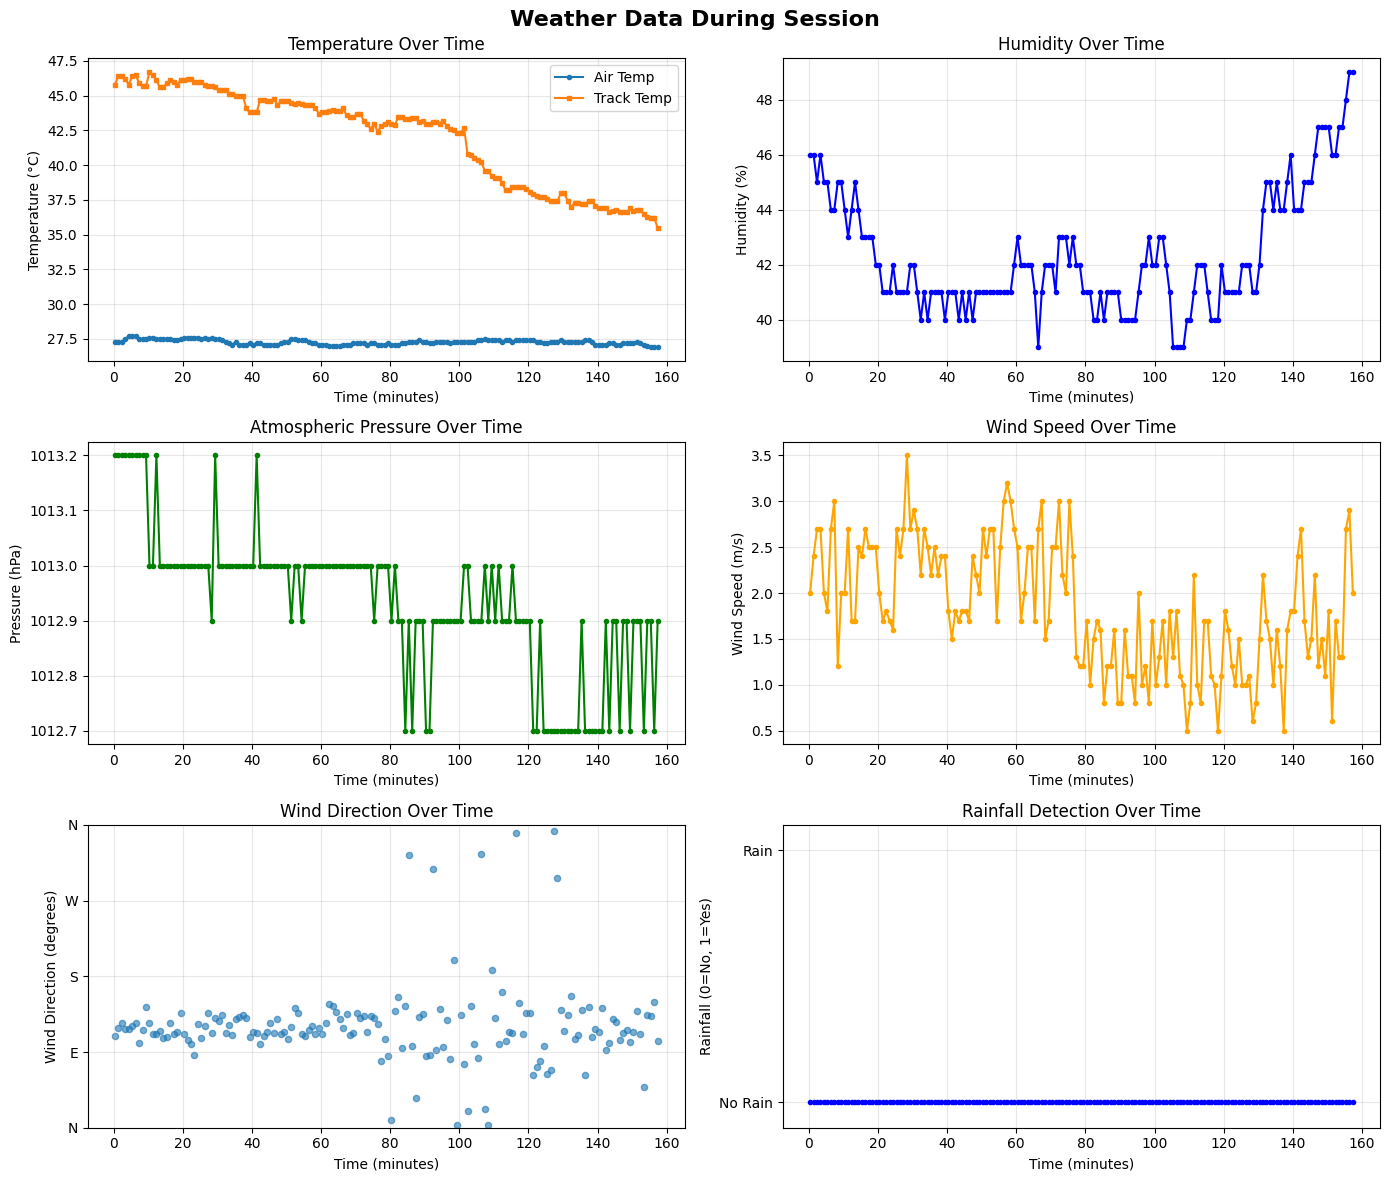

In [9]:
# Visualize weather data over time
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Weather Data During Session', fontsize=16, fontweight='bold')

# Convert Time to minutes for better readability
time_minutes = session.weather_data['Time'].dt.total_seconds() / 60

# Air and Track Temperature
ax1 = axes[0, 0]
ax1.plot(time_minutes, session.weather_data['AirTemp'], label='Air Temp', marker='o', markersize=3)
ax1.plot(time_minutes, session.weather_data['TrackTemp'], label='Track Temp', marker='s', markersize=3)
ax1.set_xlabel('Time (minutes)')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Temperature Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Humidity
ax2 = axes[0, 1]
ax2.plot(time_minutes, session.weather_data['Humidity'], color='blue', marker='o', markersize=3)
ax2.set_xlabel('Time (minutes)')
ax2.set_ylabel('Humidity (%)')
ax2.set_title('Humidity Over Time')
ax2.grid(True, alpha=0.3)

# Pressure
ax3 = axes[1, 0]
ax3.plot(time_minutes, session.weather_data['Pressure'], color='green', marker='o', markersize=3)
ax3.set_xlabel('Time (minutes)')
ax3.set_ylabel('Pressure (hPa)')
ax3.set_title('Atmospheric Pressure Over Time')
ax3.grid(True, alpha=0.3)

# Wind Speed
ax4 = axes[1, 1]
ax4.plot(time_minutes, session.weather_data['WindSpeed'], color='orange', marker='o', markersize=3)
ax4.set_xlabel('Time (minutes)')
ax4.set_ylabel('Wind Speed (m/s)')
ax4.set_title('Wind Speed Over Time')
ax4.grid(True, alpha=0.3)

# Wind Direction
ax5 = axes[2, 0]
ax5.scatter(time_minutes, session.weather_data['WindDirection'], alpha=0.6, s=20)
ax5.set_xlabel('Time (minutes)')
ax5.set_ylabel('Wind Direction (degrees)')
ax5.set_title('Wind Direction Over Time')
ax5.set_ylim(0, 360)
ax5.set_yticks([0, 90, 180, 270, 360])
ax5.set_yticklabels(['N', 'E', 'S', 'W', 'N'])
ax5.grid(True, alpha=0.3)

# Rainfall
ax6 = axes[2, 1]
ax6.plot(time_minutes, session.weather_data['Rainfall'].astype(int), color='blue', marker='o', markersize=3)
ax6.set_xlabel('Time (minutes)')
ax6.set_ylabel('Rainfall (0=No, 1=Yes)')
ax6.set_title('Rainfall Detection Over Time')
ax6.set_ylim(-0.1, 1.1)
ax6.set_yticks([0, 1])
ax6.set_yticklabels(['No Rain', 'Rain'])
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Practical Usage Examples

### 1. Getting weather at a specific time point
```python
# Get weather at 30 minutes into the session
time_point = pd.Timedelta(minutes=30)
weather_at_time = session.weather_data[session.weather_data['Time'] <= time_point].iloc[-1]
```

### 2. Merging weather data with laps
```python
# You can merge weather data with lap data using time intervals
# This requires matching Time from weather_data with LapStartTime from laps
```

### 3. Identifying weather changes during the race
```python
# Check if weather conditions changed significantly
temp_change = session.weather_data['AirTemp'].max() - session.weather_data['AirTemp'].min()
rain_during_session = session.weather_data['Rainfall'].any()
```

### 4. Using weather as features for ML models
- **AirTemp** and **TrackTemp** are excellent features (affect tire performance)
- **Humidity** and **Pressure** affect engine/aerodynamic performance
- **Rainfall** is critical for tire strategy predictions
- **WindSpeed** and **WindDirection** can affect lap times on different track sections
